In [11]:
import pandas as pd
import numpy as np
import os
from astropy import constants
from astropy import units as u

In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

In [86]:
unit_dict = {}
unit_dict['ion_lum'] = u.s**(-1)
unit_dict['luminosity'] = u.Lsun
unit_dict['radius'] = u.kpc
unit_dict['gas_surface_dens'] = u.Msun/u.kpc**2
unit_dict['star_surface_dens'] = u.Msun/u.kpc**2
unit_dict['sfr_surface_dens'] = u.Msun/u.kpc**2/u.yr
unit_dict['ionizing_flux'] = u.kpc**(-2)*u.s**(-1)

In [87]:
path = '/ptmp/mpa/ivkos/semianalytic_fesc/df_snap013_lv0.pickle'
df = pd.read_pickle(path)

In [88]:
# Temporary to be removed later
df['redshift'] = 6.0107573988449

Level 1

In [130]:
Z_solar = 0.0134
df['Dust_normalized'] = df['Z']/Z_solar
df['Gas_fraction'] = df['gas_surface_dens']/(df['gas_surface_dens']+df['star_surface_dens'])
df['Galaxy_rotation_frequency'] = 0.41*(1+df['redshift'])**(2/3)

df['Bolometric_flux'] = df['luminosity']/(np.pi*df['radius']**2)
unit_dict['Bolometric_flux'] = unit_dict['luminosity']/(unit_dict['radius']**2)

Level 2

In [90]:
df['Velocity_dispersion'] = df['sfr_surface_dens']/(df['Gas_fraction']*df['Galaxy_rotation_frequency'])**2
unit_dict['Velocity_dispersion'] = u.km/u.s

df['Critical_column_dens'] = 4.3e20/df['Dust_normalized']
unit_dict['Critical_column_dens'] = u.cm**(-2)

df['Gravitational_pressure'] = np.pi/2*constants.G.value*df['gas_surface_dens']**2/df['Gas_fraction']
unit_dict['Gravitational_pressure'] = constants.G.unit*unit_dict['gas_surface_dens']**2

df['Dust_cross_per_H'] = 4.8e-22*df['Dust_normalized']
unit_dict['Dust_cross_per_H'] = u.cm**2

Level 3

In [91]:
df['Column_height'] = df['Velocity_dispersion']**2/(np.pi*constants.G.value*(df['gas_surface_dens']+df['star_surface_dens']))
unit_dict['Column_height'] = unit_dict['Velocity_dispersion']**2/(constants.G.unit*unit_dict['gas_surface_dens'])

Level 4

In [92]:
mu = 1 #Mean molecular weight to be adjusted later
df['Particle_dens'] = df['gas_surface_dens']/(mu*constants.m_p.value*df['Column_height'])
unit_dict['Particle_dens'] = unit_dict['gas_surface_dens']/(constants.m_p.unit*unit_dict['Column_height'])

Level 5

In [93]:
unit_corr_photon_to_gas = float(1*unit_dict['ionizing_flux']/(unit_dict['Particle_dens']*constants.c.unit))
df['Photon_to_gas'] = df['ionizing_flux']/(df['Particle_dens']*constants.c.value)*unit_corr_photon_to_gas

df['Gas_column_dens'] = df['Particle_dens']*df['Column_height']
unit_dict['Gas_column_dens'] = unit_dict['Particle_dens']*unit_dict['Column_height']

Level 6

In [94]:
df['U1'] = df['Gas_fraction']**3*df['Photon_to_gas']

case_B_param = 2.6e-13*u.cm**3/u.s
df['Column_dens_stroemgren'] = df['Gas_fraction']*constants.c.value/case_B_param.value
unit_dict['Column_dens_stroemgren'] = constants.c.unit/case_B_param.unit

unit_corr_optical_depth = float(1*unit_dict['Dust_cross_per_H']*unit_dict['Gas_column_dens'])
df['Optical_depth'] = df['Dust_cross_per_H']*df['Gas_column_dens']*unit_corr_optical_depth

Level 7

In [131]:
df['Radiation_pressure'] = (1-np.exp(-1*df['Optical_depth']))*df['Bolometric_flux']/constants.c.value
unit_dict['Radiation_pressure'] = unit_dict['Bolometric_flux']/constants.c.unit

N_ratio_corr = float(1*unit_dict['Gas_column_dens']/unit_dict['Critical_column_dens'])
df['N_ratio'] = df['Gas_column_dens']/df['Critical_column_dens']*N_ratio_corr

Level 8

In [164]:
unit_corr_rad_pressure = unit_dict['Radiation_pressure'].to(u.Pa)
unit_corr_grav_pressure = unit_dict['Gravitational_pressure'].to(u.Pa)

df['Radiation_pressure'] = df['Radiation_pressure']*unit_corr_rad_pressure
df['Gravitational_pressure'] = df['Gravitational_pressure']*unit_corr_grav_pressure

unit_dict['Radiation_pressure'] = u.Pa
unit_dict['Gravitational_pressure'] = u.Pa

df['Outflow_velocity'] = (2*df['Column_height']*(df['Radiation_pressure']-df['Gravitational_pressure'])/df['gas_surface_dens'])**0.5
unit_dict['Outflow_velocity'] = (unit_dict['Column_height']*unit_dict['Radiation_pressure']/unit_dict['gas_surface_dens'])**0.5

df['Critical_gas_fraction'] = 6*(df['Dust_normalized']*df['U1']*((1-df['N_ratio'])/df['N_ratio']))

Level 9

In [165]:
t_OB = 2*u.Myr
df['Reduced_column_dens'] = (1-0.5*df['Outflow_velocity']*t_OB.value/df['Column_height'])*df['Gas_column_dens']
unit_dict['Reduced_column_dens'] = unit_dict['Outflow_velocity']*t_OB.unit/unit_dict['Column_height']*unit_dict['Gas_column_dens']

In [166]:
def escape_fraction(element):
    return np.exp(-element['Reduced_column_dens']*(1/element['Column_dens_stroemgren']+1/element['Critical_column_dens']))   

Level 10

In [167]:
unit_corr_reduced_colum_dens = unit_dict['Reduced_column_dens'].to(u.cm**(-2))
unit_corr_column_dens_stroemgren = unit_dict['Column_dens_stroemgren'].to(u.cm**(-2))
unit_corr_crit_column_dens = unit_dict['Critical_column_dens'].to(u.cm**(-2))

unit_dict['Reduced_column_dens'] = u.cm**(-2)
unit_dict['Column_dens_stroemgren'] = u.cm**(-2)
unit_dict['Critical_column_dens'] = u.cm**(-2)

df['Reduced_column_dens'] = df['Reduced_column_dens']*unit_corr_reduced_colum_dens
df['Column_dens_stroemgren'] = df['Column_dens_stroemgren']*unit_corr_column_dens_stroemgren
df['Column_dens_stroemgren'] = df['Column_dens_stroemgren']*unit_corr_crit_column_dens

df['escape_fraction'] = df.apply(lambda x: 0 if x['Gas_fraction']<x['Critical_gas_fraction'] else escape_fraction(x), axis=1)

In [168]:
df

,HaloMass,GasMass,StarMass,SFR,com_radius,Z,ion_lum,luminosity,radius,gas_surface_dens,...,U1,Column_dens_stroemgren,Optical_depth,Radiation_pressure,N_ratio,Outflow_velocity,Critical_gas_fraction,Reduced_column_dens,Bolometric_flux,escape_fraction
0,3.268400,0.690410,2.306308,391.632721,1.191221,0.015532,8.783616e+45,3.999875e+12,12.328552,2.134459e+07,...,3.420863e-14,2.656492e+22,1.482734e+00,8.683463e-12,7.183790,4.196415e-08,-2.047931e-13,8.410054e+31,8.376689e+09,0.0
1,0.796984,0.119877,0.012056,1.798865,17.856184,0.002725,8.783616e+45,2.576770e+10,184.802737,1.649396e+04,...,1.065424e-19,1.047687e+23,2.009986e-04,6.473042e-20,0.000974,NaN,1.333482e-16,NaN,2.401646e+05,NaN
2,0.261141,0.028767,0.006582,0.346269,12.280504,0.004793,8.783616e+45,7.860428e+09,127.097189,8.368070e+03,...,1.449399e-19,9.383472e+22,1.793872e-04,3.725864e-20,0.000869,NaN,3.576003e-16,NaN,1.548904e+05,NaN
3,0.471234,0.042249,0.003220,0.122709,26.634462,0.001956,8.783616e+45,1.804564e+09,275.653608,2.612701e+03,...,1.793967e-21,1.071389e+23,2.285744e-05,2.317224e-22,0.000111,NaN,1.418696e-17,NaN,7.559536e+03,NaN
4,0.171911,0.014199,0.003198,0.115020,11.067033,0.005315,8.783616e+45,2.300317e+09,114.538356,5.085739e+03,...,8.082684e-20,9.410754e+22,1.208849e-04,9.047569e-21,0.000586,NaN,3.282160e-16,NaN,5.581306e+04,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2368557,0.001249,0.000103,0.000009,0.000017,2.587251,0.000578,8.783616e+45,2.099992e+06,26.776775,6.753710e+02,...,6.394082e-22,1.058745e+23,1.744863e-06,2.181536e-24,0.000008,NaN,1.956342e-17,NaN,9.322905e+02,NaN
2422910,0.002738,0.000422,0.000010,0.000032,5.214189,0.000685,8.783616e+45,2.863150e+06,53.964297,6.813519e+02,...,3.233923e-23,1.126210e+23,2.088170e-06,8.763883e-25,0.000010,NaN,9.807683e-19,NaN,3.129545e+02,NaN
2434511,0.003374,0.000415,0.000008,0.000016,6.861280,0.000441,8.783616e+45,1.427849e+06,71.010884,3.869868e+02,...,4.714910e-24,1.132103e+23,7.640364e-07,9.235207e-26,0.000004,NaN,2.517609e-19,NaN,9.013275e+01,NaN
2521336,0.002144,0.000232,0.000007,0.000026,4.469308,0.000406,8.783616e+45,9.879400e+05,46.255147,5.100107e+02,...,9.313319e-23,1.121475e+23,9.256188e-07,1.824495e-25,0.000004,NaN,3.773426e-18,NaN,1.469808e+02,NaN


In [178]:
df['GraviationPressure']

KeyError: 'GraviationPressure'

In [186]:
from matplotlib import pyplot as plt

(1e-32, 1e-10)

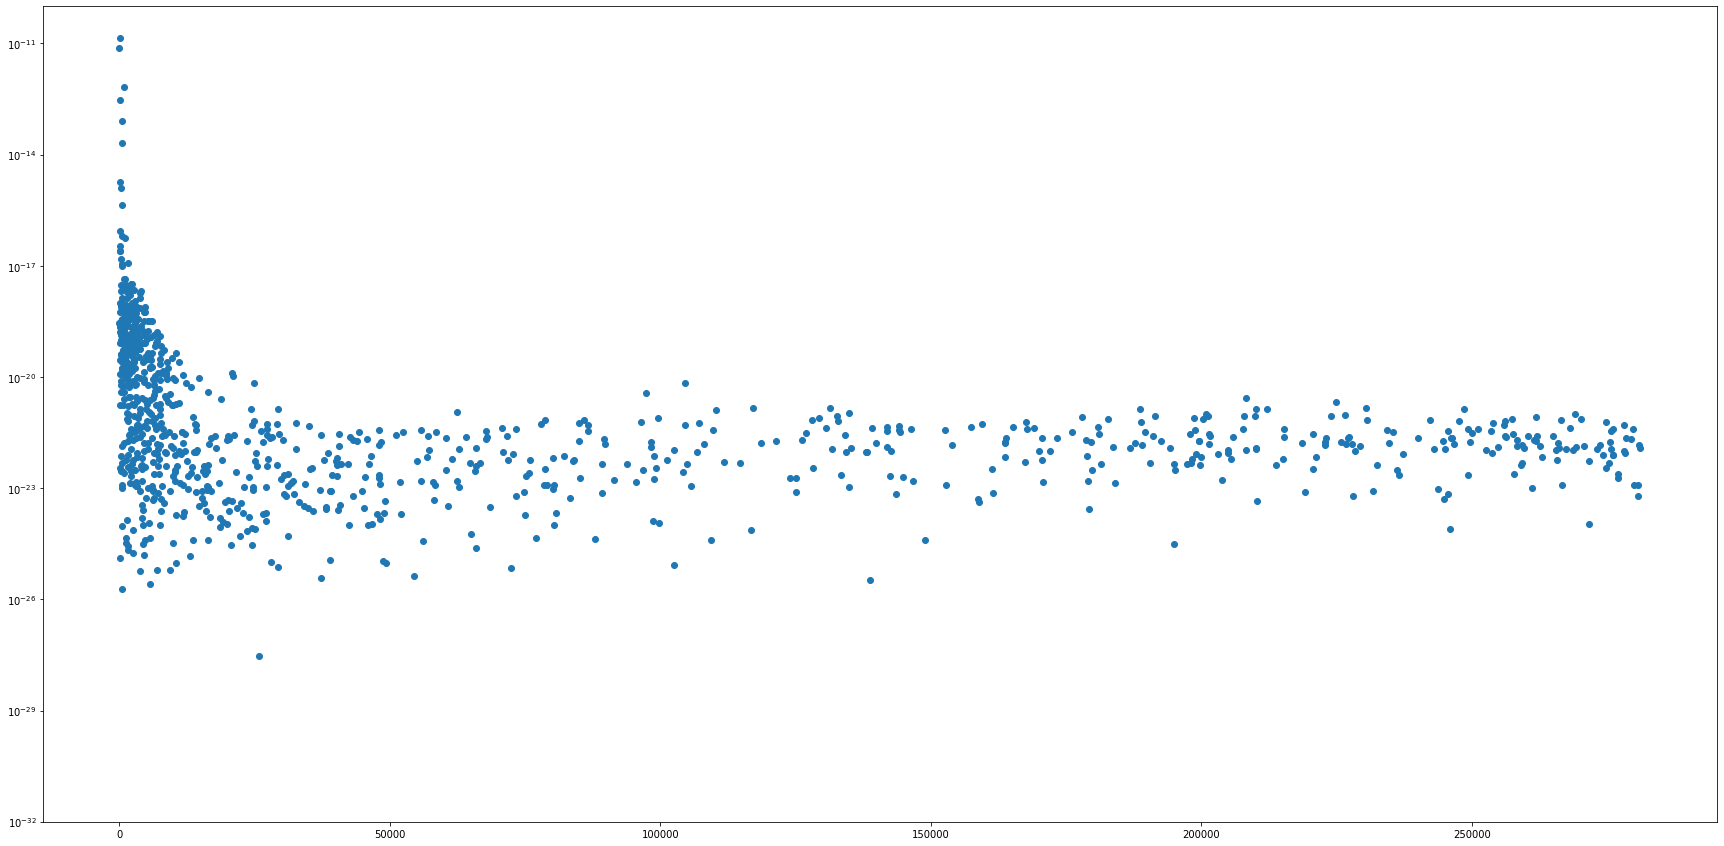

In [192]:
plt.scatter(np.arange(len(df)), df['Radiation_pressure']-df['Gravitational_pressure'])
plt.rcParams['figure.figsize'] = [30, 15]
plt.yscale('log')
plt.ylim(1e-32,1e-10)

In [171]:
df[df['Outflow_velocity'] > 0]['HaloMass'].mean()

0.104005374

In [158]:
unit_dict['Gravitational_pressure'].to(u.Pa)

4.3612365173332226e-18

In [160]:
df['Gravitational_pressure']

0          207319.464454
1               0.031390
2               0.009021
3               0.000770
4               0.003322
               ...      
2368557         0.000052
2422910         0.000050
2434511         0.000016
2521336         0.000028
2745125         0.000081
Name: Gravitational_pressure, Length: 281343, dtype: float64

In [161]:
df['Radiation_pressure']

0          2.159843e+01
1          1.610043e-07
2          9.267364e-08
3          5.763644e-10
4          2.250407e-08
               ...     
2368557    5.426146e-12
2422910    2.179846e-12
2434511    2.297078e-13
2521336    4.538076e-13
2745125    6.168920e-13
Name: Radiation_pressure, Length: 281343, dtype: float64

In [155]:
for idx in df.index:
    if idx < 1000:
        print((2*df.loc[idx]['Column_height']*(df.loc[idx]['Radiation_pressure']-df.loc[idx]['Gravitational_pressure'])/df.loc[idx]['gas_surface_dens'])**0.5)
    else:
        break

nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


<ipython-input-155-a117f0ae8552>:3: RuntimeWarning: invalid value encountered in double_scalars
  print((2*df.loc[idx]['Column_height']*(df.loc[idx]['Radiation_pressure']-df.loc[idx]['Gravitational_pressure'])/df.loc[idx]['gas_surface_dens'])**0.5)


In [122]:
unit_dict['Radiation_pressure'].to(u.Pa)

UnitConversionError: 's solLum / m' (force) and 'Pa' (pressure) are not convertible

In [123]:
unit_dict['Gravitational_pressure'].to(u.Pa)

4.3612365173332226e-18

In [115]:
(u.kg*u.m**2/u.s**3)**0.5*u.s**1.5/u.kg**0.5/u.m**2

Unit("1 / m")

In [110]:
 unit_dict['Column_dens_stroemgren']

Unit("m / cm3")

In [106]:
unit_corr_column_dens_stroemgren = unit_dict['Column_dens_stroemgren'].to(u.cm**(-2))

In [107]:
unit_corr_crit_column_dens = unit_dict['Critical_column_dens'].to(u.cm**(-2))

In [108]:
unit_corr_column_dens_stroemgren

99.99999999999999

In [109]:
unit_corr_crit_column_dens

1.0